In [162]:
# Data manipulation and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
import warnings
warnings.filterwarnings('ignore')

# Deep Learning libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input, Conv2D, MaxPooling2D, Flatten, BatchNormalization
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Scikit-learn for metrics
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [64]:
patient_df = pd.read_csv('./skin-cancer-mnist-ham10000/HAM10000_metadata.csv')

## Checking the Data & Cleaning

In [65]:
patient_df

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear
...,...,...,...,...,...,...,...
10010,HAM_0002867,ISIC_0033084,akiec,histo,40.0,male,abdomen
10011,HAM_0002867,ISIC_0033550,akiec,histo,40.0,male,abdomen
10012,HAM_0002867,ISIC_0033536,akiec,histo,40.0,male,abdomen
10013,HAM_0000239,ISIC_0032854,akiec,histo,80.0,male,face


In [66]:
patient_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB


In [67]:
patient_df.describe()

,age
count,9958.000000
mean,51.863828
std,16.968614
min,0.000000
25%,40.000000
50%,50.000000
75%,65.000000
max,85.000000


Based on these summaries of the dataset, there are 10015 rows of data within the HAM10000 skin lesion dataset.

The dataset contains information on the lesion and image id, the type of disease the patient has (dx column), the type of test the patient had (dx_type column), the patient's age, sex and where the skin lesion is located on. 

Age is the only numerical variable in the entire dataset, and the mean age is roughly 51.8 years old. 

In [68]:
patient_df.isna().sum()

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64

In [69]:
patient_df.duplicated().sum()

0

In [70]:
patient_df['age'] = patient_df['age'].fillna(patient_df['age'].mean().round(1))

There are 57 missing values for the age column of the dataset, so I filled up all the missing values with the mean of the overall patients' age. 

In [71]:
patient_df.isna().sum()

lesion_id       0
image_id        0
dx              0
dx_type         0
age             0
sex             0
localization    0
dtype: int64

Below I mapped out readable labels to better identify all the different skin lesions. 

In [72]:
lesion_type_dict = {
    'nv': 'Melanocytic nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis-like lesions ',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}

In [73]:
patient_df['cell_type'] = patient_df['dx'].map(lesion_type_dict)
patient_df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,cell_type
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,Benign keratosis-like lesions
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,Benign keratosis-like lesions
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,Benign keratosis-like lesions
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,Benign keratosis-like lesions
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,Benign keratosis-like lesions


Below shows a few invalid records (the patient's age is 0 and their gender is unknown), I filtered and removed these records from the dataset to ensure data integrity.

In [74]:
patient_df['age'].value_counts()

age
45.0    1299
50.0    1187
55.0    1009
40.0     985
60.0     803
70.0     756
35.0     753
65.0     731
75.0     618
30.0     464
80.0     404
85.0     290
25.0     247
20.0     169
5.0       86
15.0      77
51.9      57
10.0      41
0.0       39
Name: count, dtype: int64

In [75]:
patient_df = patient_df[patient_df['age']!=0]

In [76]:
patient_df['sex'].value_counts()

sex
male       5383
female     4538
unknown      55
Name: count, dtype: int64

In [77]:
patient_df = patient_df[patient_df['sex']!='unknown']

In [196]:
patient_df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,cell_type,image_path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,Benign keratosis-like lesions,ISIC_0027419.jpg
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,Benign keratosis-like lesions,ISIC_0025030.jpg
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,Benign keratosis-like lesions,ISIC_0026769.jpg
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,Benign keratosis-like lesions,ISIC_0025661.jpg
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,Benign keratosis-like lesions,ISIC_0031633.jpg


## Exploratory Data Analysis (EDA)

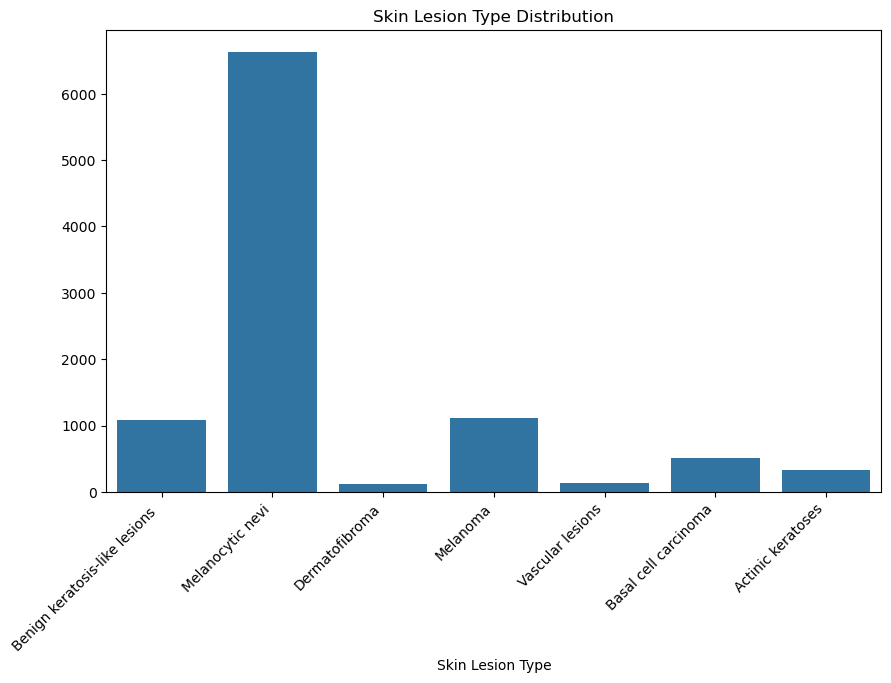

In [103]:
plt.figure(figsize=(10,6))
sns.countplot(data=patient_df, x='cell_type')
plt.xticks(rotation=45,ha='right')
plt.title('Skin Lesion Type Distribution')
plt.xlabel('Skin Lesion Type')
plt.ylabel('')
plt.show()

A majority of patients have Melanocytic Nevi, a benign skin lesion. 

The type of skin lesion that is least identified in patients is Dermatofibroma, also a benign skin lesion. 

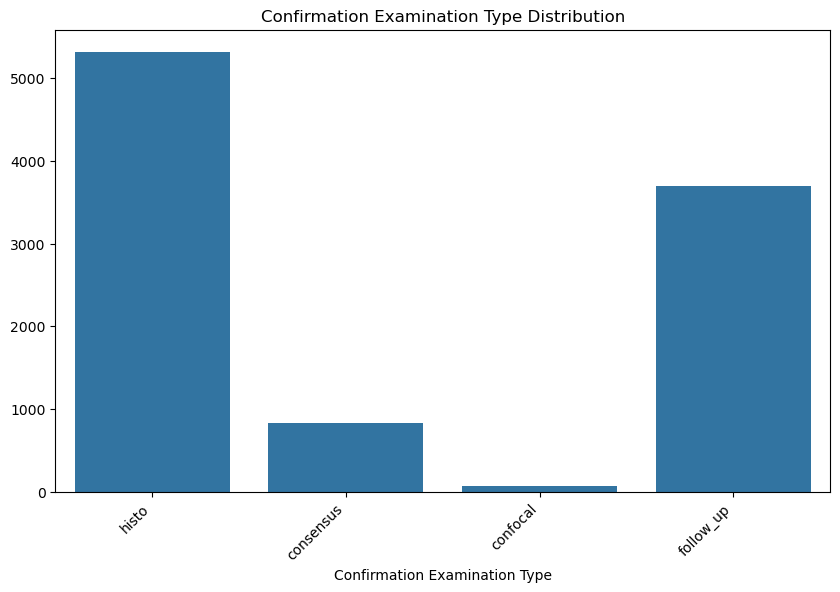

In [102]:
plt.figure(figsize=(10,6))
sns.countplot(data=patient_df, x='dx_type')
plt.xticks(rotation=45,ha='right')
plt.title('Confirmation Examination Type Distribution')
plt.xlabel('Confirmation Examination Type')
plt.ylabel('')
plt.show()

Most patients confirmed the type of skin lesion they had through a histopathology (histo), whereas the least amount of patients got confirmation by in-vivo confocal microscopy (confocal) 

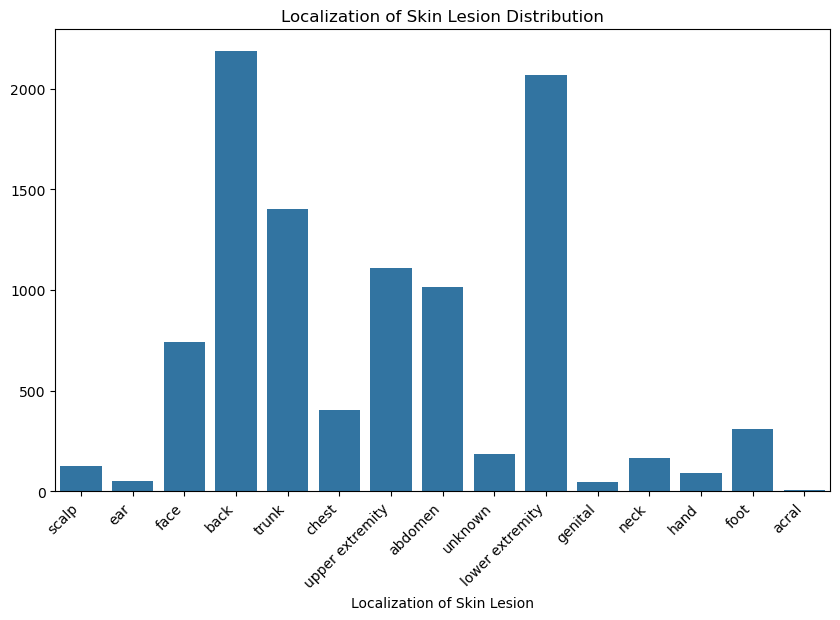

In [101]:
plt.figure(figsize=(10,6))
sns.countplot(data=patient_df, x='localization')
plt.xticks(rotation=45,ha='right')
plt.title('Localization of Skin Lesion Distribution')
plt.xlabel('Localization of Skin Lesion')
plt.ylabel('')
plt.show()

Most skin lesions tend to grow on the back, whereas only 7 patients have been confirmed to have skin lesions on their acral body parts, which are the hands, feet, ears or nose of a patient.

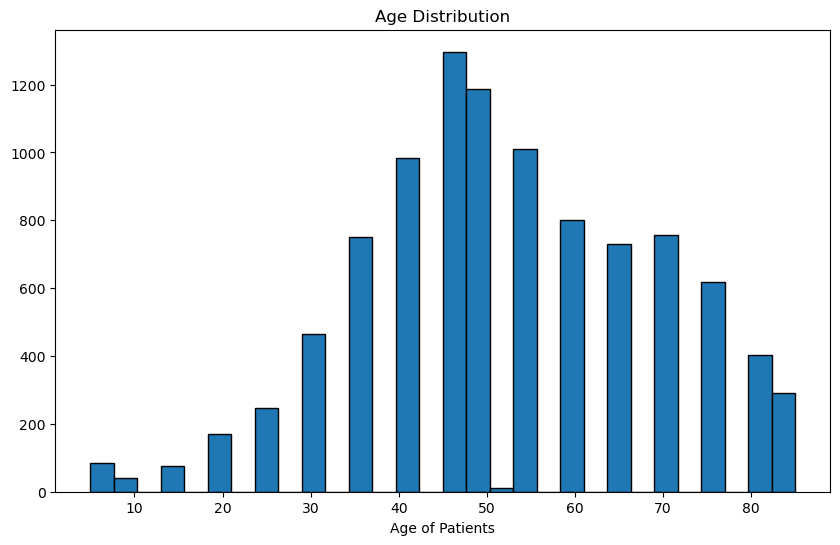

In [104]:
plt.figure(figsize=(10,6))
plt.hist(x=patient_df['age'], bins=30, edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age of Patients')
plt.ylabel('')
plt.show()

Most patients are around the age of 35 to 60 years old.

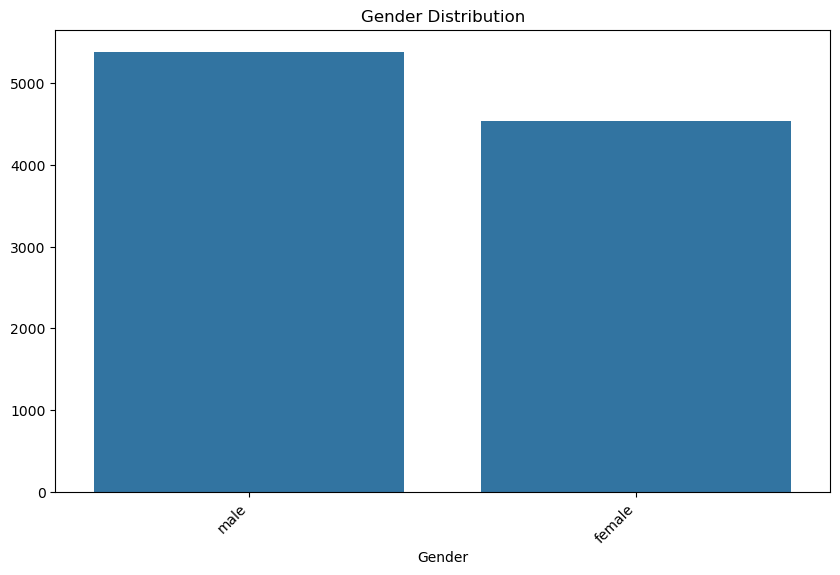

In [105]:
plt.figure(figsize=(10,6))
sns.countplot(data=patient_df, x='sex')
plt.xticks(rotation=45,ha='right')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('')
plt.show()

Most patients are male.

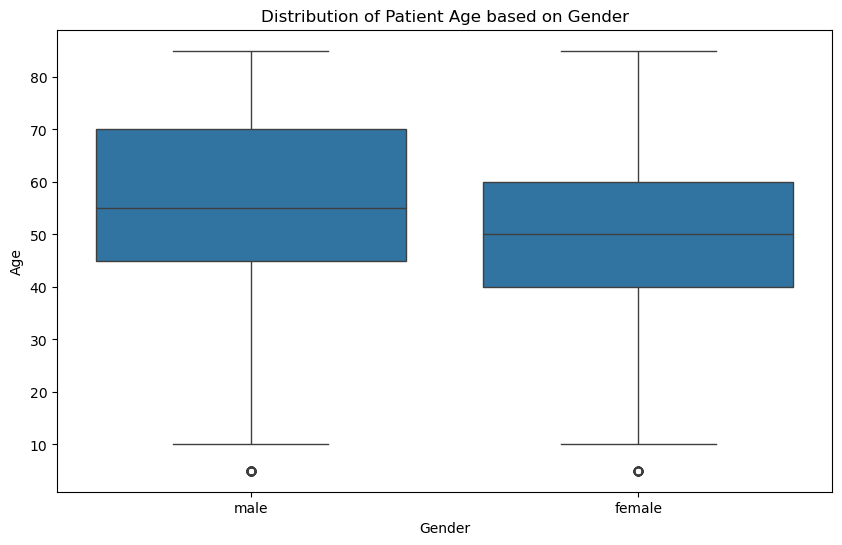

In [121]:
plt.figure(figsize=(10,6))
sns.boxplot(data=patient_df, x='sex', y='age')
plt.title('Distribution of Patient Age based on Gender')
plt.xlabel('Gender')
plt.ylabel('Age')
plt.show()

Most male patients are between the age group of 45 - 70 years old while most female patients are between the ages of 40 - 60 years old. 

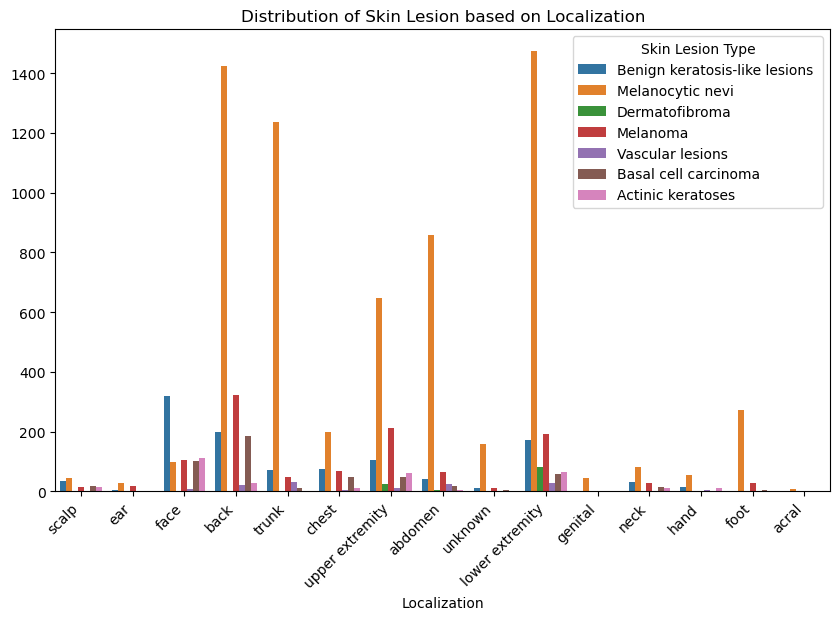

In [98]:
plt.figure(figsize=(10,6))
sns.countplot(data=patient_df, x='localization', hue='cell_type')
plt.xticks(rotation=45,ha='right')
plt.title('Distribution of Skin Lesion based on Localization')
plt.xlabel('Localization')
plt.ylabel('')
plt.legend(title='Skin Lesion Type',bbox_to_anchor=(1,1))
plt.show()

Melanocytic nevi is most commonly diagnosed in all areas of the body except for the face. 

The majority of skin lesions found on the face are Benign keratosis-like lesions. 

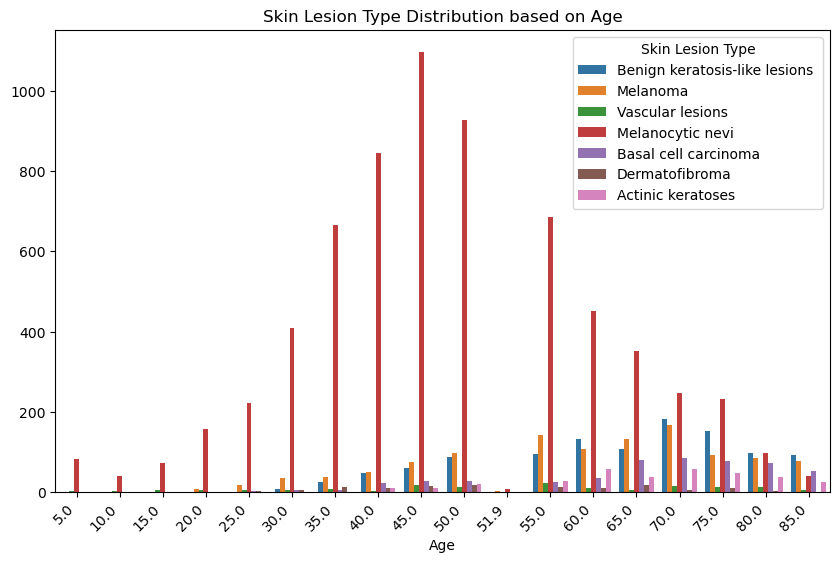

In [109]:
plt.figure(figsize=(10,6))
sns.countplot(data=patient_df, x='age', hue='cell_type')
plt.xticks(rotation=45,ha='right')
plt.title('Skin Lesion Type Distribution based on Age')
plt.xlabel('Age')
plt.ylabel('')
plt.legend(title='Skin Lesion Type',bbox_to_anchor=(1,1))
plt.show()

Melanocytic nevi is most commonly diagnosed across all age groups except for 80 years old and above. 

For patients within the age groups of 80 and above, Benign keratosis-like lesions are more common. 

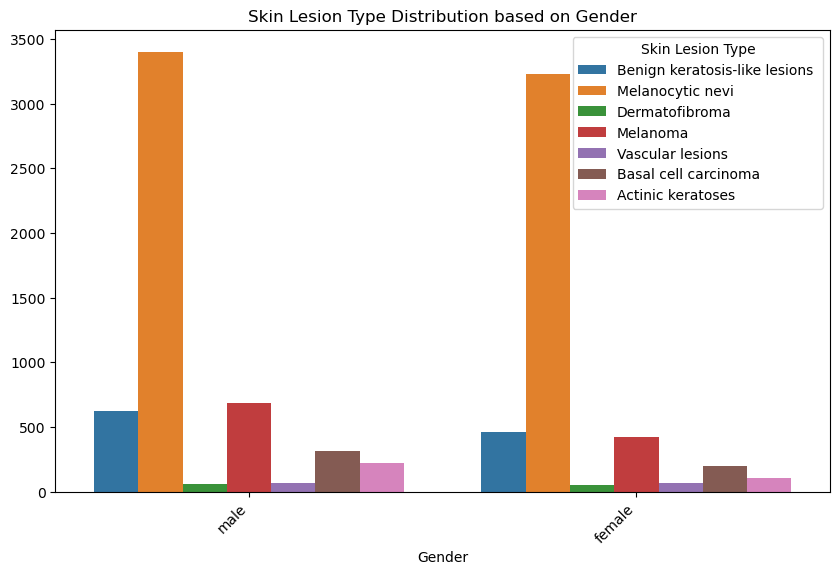

In [110]:
plt.figure(figsize=(10,6))
sns.countplot(data=patient_df, x='sex', hue='cell_type')
plt.xticks(rotation=45,ha='right')
plt.title('Skin Lesion Type Distribution based on Gender')
plt.xlabel('Gender')
plt.ylabel('')
plt.legend(title='Skin Lesion Type',bbox_to_anchor=(1,1))
plt.show()

Melanocytic nevi is most commonly diagnosed among both male and female patients.

## Preparing the Data

Creating an image path to link the image with its corresponding data in the dataframe

In [112]:
patient_df['image_path'] = patient_df['image_id'].astype(str) + '.jpg'

Preparing the directory paths and setting up image parameters for processing

In [113]:
BASE_DIR = Path('./skin-cancer-mnist-ham10000')  # Update this to your data directory
TRAIN_DIR = BASE_DIR / 'train'
TEST_DIR = BASE_DIR / 'test'
SAMPLE_DIR = BASE_DIR / 'sample'

# Image parameters
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_CHANNELS = 3
BATCH_SIZE = 32
TARGET_SIZE = (IMG_HEIGHT, IMG_WIDTH)

print(f"{TRAIN_DIR}\nTrain directory exists: {TRAIN_DIR.exists()}")
print(f"{TEST_DIR}\nTest directory exists: {TEST_DIR.exists()}")
print(f"{SAMPLE_DIR}\nSample directory exists: {SAMPLE_DIR.exists()}")

skin-cancer-mnist-ham10000\train
Train directory exists: True
skin-cancer-mnist-ham10000\test
Test directory exists: True
skin-cancer-mnist-ham10000\sample
Sample directory exists: True


In [114]:
# Count images in each set
def count_images(directory):
    return len(list(directory.glob('*.jpg')))
    
# Count images in each set
train_total = count_images(TRAIN_DIR)
test_total = count_images(TEST_DIR)

print(f"Training images: {train_total}")
print(f"Test images: {test_total}")

Training images: 8000
Test images: 2015


Sample a few images from the training directory. 

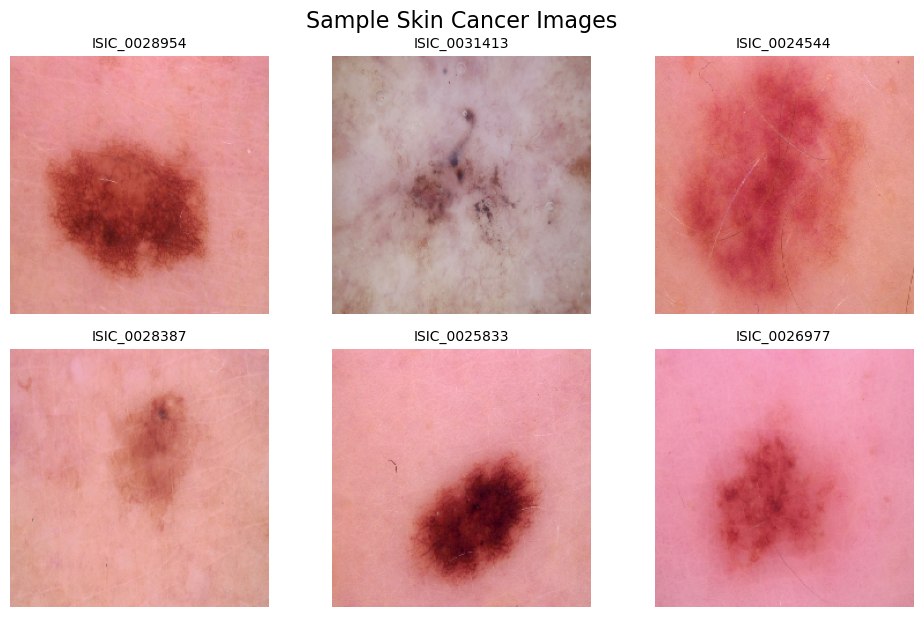

In [115]:
def plot_sample_images(directory, num_samples=12, figsize=(10, 6)):
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    axes = axes.ravel()
    images = list(directory.glob('*.jpg'))

    for idx in range(0,6):
        if images:
            random_image = np.random.choice(images)
            img = load_img(random_image, target_size=(IMG_HEIGHT, IMG_WIDTH))

            axes[idx].imshow(img)
            axes[idx].set_title(random_image.stem, fontsize=10)
            axes[idx].axis('off')
    
    plt.tight_layout()
    plt.suptitle('Sample Skin Cancer Images', fontsize=16, y=1.02)
    plt.show()

plot_sample_images(TRAIN_DIR)

## Sample Skin Cancer Images with Class

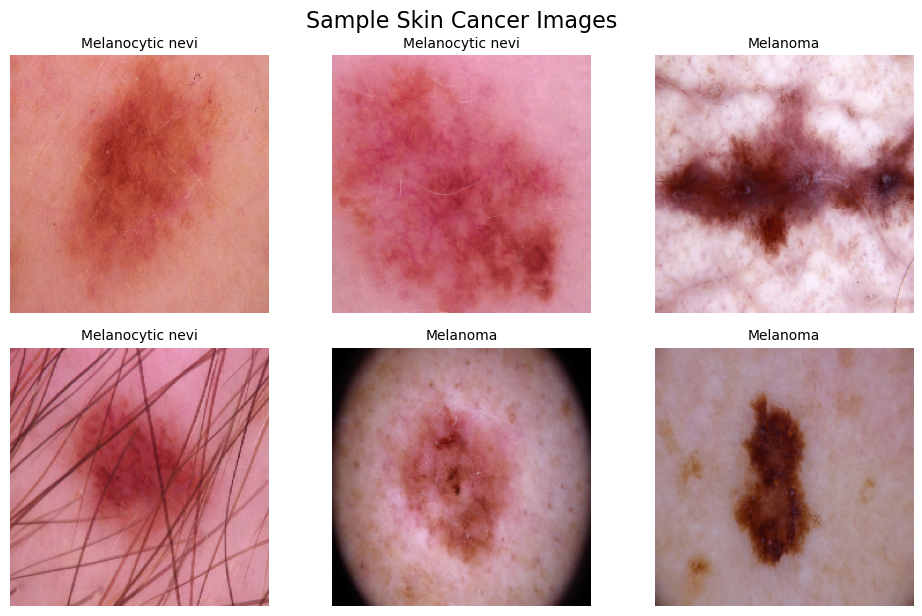

In [204]:
def plot_sample_images_by_class(directory, num_samples=12, figsize=(10, 6)):
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    axes = axes.ravel()
    images = list(directory.glob('*.jpg'))

    for idx in range(0,6):
        if images:
            random_image = np.random.choice(images)
            img = load_img(random_image, target_size=(IMG_HEIGHT, IMG_WIDTH))

            label = patient_df[patient_df['image_id']==random_image.stem]

            label_text = label['cell_type'].values[0]

            axes[idx].imshow(img)
            axes[idx].set_title(label_text, fontsize=10)
            axes[idx].axis('off')
    
    plt.tight_layout()
    plt.suptitle('Sample Skin Cancer Images', fontsize=16, y=1.02)
    plt.show()

plot_sample_images_by_class(TRAIN_DIR)

## Data Augmentation

In [153]:
train_data = ImageDataGenerator(
    rescale=1./255, # normalize pixels values to 0-1
    rotation_range=40, # rotating images up 40 degress 
    width_shift_range=0.2, # randomly shiftting horizontally by 20%
    height_shift_range=0.2, # randomly shifting vertically by 20%
    shear_range=0.2, # shear transformation
    zoom_range=0.2, # random zoom by 20%
    horizontal_flip=True, # random horizontal flip
)

test_data = ImageDataGenerator(
    rescale=1./255 # normalize pixels values to 0-1
)

## Training & Testing Generators for the Model

In [143]:
# AI GENERATED code for getting data of images from the dataframe
train_gen = train_data.flow_from_dataframe(
    dataframe=patient_df,
    directory=TRAIN_DIR,
    x_col='image_path',
    y_col='cell_type',  
    target_size=TARGET_SIZE,
    class_mode='sparse',
    batch_size=BATCH_SIZE
)

test_gen = test_data.flow_from_dataframe(
    dataframe=patient_df,
    directory=TEST_DIR,
    x_col='image_path',
    y_col='cell_type',
    target_size=TARGET_SIZE,
    class_mode='sparse',
    batch_size=BATCH_SIZE
)

## get class labels and number of classes from generators
class_names = list(test_gen.class_indices.keys())
num_classes = len(class_names)

Found 7929 validated image filenames belonging to 7 classes.
Found 1992 validated image filenames belonging to 7 classes.


## Visualizing the Data Augmentation

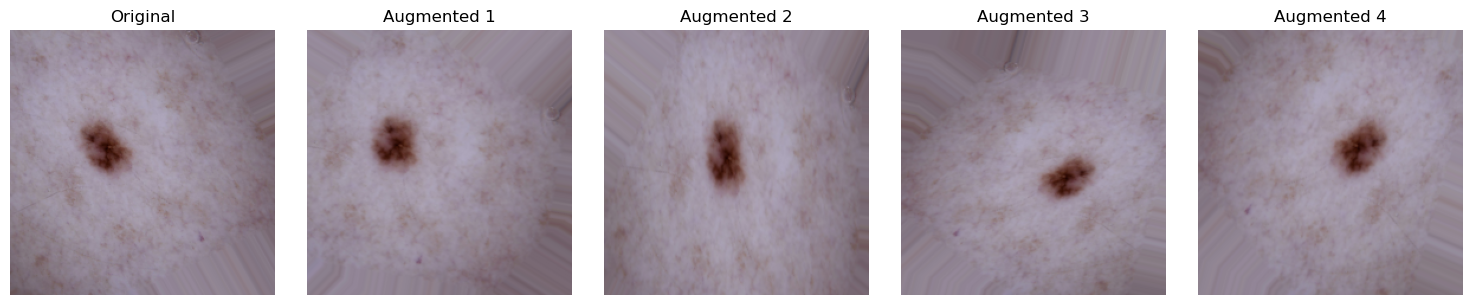

In [207]:
def visualize_augmentation(generator, num_images=5):
    """Visualize augmented versions of a single image."""
    # Get a batch of images
    x_batch, y_batch = next(generator)
    
    # Take the first image
    img = x_batch[0]
    
    # Create augmented versions
    fig, axes = plt.subplots(1, num_images, figsize=(15, 3))
    
    axes[0].imshow(img)
    axes[0].set_title('Original')
    axes[0].axis('off')
    
    # AI generated code to show augmented versions
    img_array = img * 255.0 ## image has already been rescaled in train_data, so return it back to original size to be rescaled later by below code
    img_array = img_array.reshape((1,) + img_array.shape) 
    
    aug_iter = train_data.flow(img_array, batch_size=1)
    
    for i in range(1, num_images):
        batch = next(aug_iter)
        aug_img = batch[0]
        axes[i].imshow(aug_img)
        axes[i].set_title(f'Augmented {i}')
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

visualize_augmentation(train_gen)

## Building a simple CNN model

In [172]:
simple_model = Sequential([
    Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(224, 224, 3)), 
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=128, kernel_size=(3,3), activation='relu'),  
    MaxPooling2D(pool_size=(2,2)),
    Flatten(), 
    BatchNormalization(),
    Dense(512, activation='relu'),
    Dropout(0.5), 
    Dense(units=num_classes, activation='softmax')
])

simple_model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_31 (Conv2D)                   │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_22 (MaxPooling2D)      │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_32 (Conv2D)                   │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_23 (MaxPooling2D)      │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_33 (Conv2D)                   │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_24 (MaxPooling2D)      │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_7 (Flatten)                  │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_30               │ (None, 86528)               │         346,112 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_35 (Dense)                     │ (None, 512)                 │      44,302,848 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_34 (Dropout)                 │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_36 (Dense)                     │ (None, 7)                   │           3,591 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 44,745,799 (170.69 MB)

 Trainable params: 44,572,743 (170.03 MB)

 Non-trainable params: 173,056 (676.00 KB)

In [173]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',metrics=['accuracy'])

EPOCHS = 15
PATIENCE = 7

early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=PATIENCE, 
    restore_best_weights=True
)

history1 = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=EPOCHS,
    callbacks=[early_stopping]
)

Epoch 1/15
248/248 ━━━━━━━━━━━━━━━━━━━━ 205s 821ms/step - accuracy: 0.7002 - loss: 0.8100 - val_accuracy: 0.6687 - val_loss: 0.8508
Epoch 2/15
248/248 ━━━━━━━━━━━━━━━━━━━━ 211s 850ms/step - accuracy: 0.7011 - loss: 0.7923 - val_accuracy: 0.6878 - val_loss: 0.7994
Epoch 3/15
248/248 ━━━━━━━━━━━━━━━━━━━━ 206s 832ms/step - accuracy: 0.7006 - loss: 0.7903 - val_accuracy: 0.7038 - val_loss: 0.7943
Epoch 4/15
248/248 ━━━━━━━━━━━━━━━━━━━━ 223s 898ms/step - accuracy: 0.7095 - loss: 0.7680 - val_accuracy: 0.7013 - val_loss: 0.7858
Epoch 5/15
248/248 ━━━━━━━━━━━━━━━━━━━━ 205s 824ms/step - accuracy: 0.7106 - loss: 0.7618 - val_accuracy: 0.6943 - val_loss: 0.8150
Epoch 6/15
248/248 ━━━━━━━━━━━━━━━━━━━━ 221s 892ms/step - accuracy: 0.7088 - loss: 0.7565 - val_accuracy: 0.7169 - val_loss: 0.7493
Epoch 7/15
248/248 ━━━━━━━━━━━━━━━━━━━━ 213s 859ms/step - accuracy: 0.7075 - loss: 0.7484 - val_accuracy: 0.7038 - val_loss: 0.7643
Epoch 8/15
248/248 ━━━━━━━━━━━━━━━━━━━━ 205s 824ms/step - accuracy: 0.7180 -

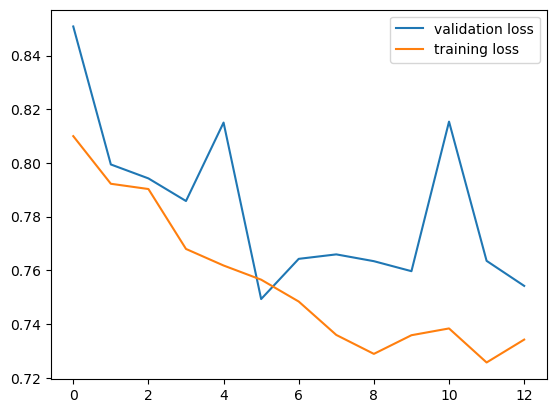

In [174]:
plt.plot(history1.history['val_loss'],label='validation loss')
plt.plot(history1.history['loss'],label='training loss')
plt.legend()
plt.show()

In [175]:
y_pred1 = model.predict(test_gen)

63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 218ms/step


In [176]:
pred_classes1 = y_pred1.argmax(axis=1)
pred_classes1 = pred_classes1[:test_gen.samples] ## get the first 1992 out of 13944 data so that the shape for confusion matrix is the same

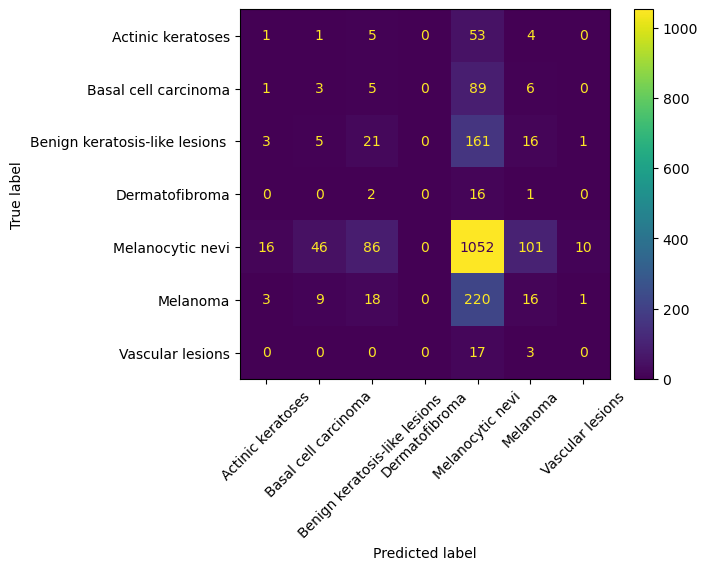

In [177]:
ConfusionMatrixDisplay.from_predictions(test_gen.classes, pred_classes1, display_labels=class_names, xticks_rotation=45)
plt.show()

In [178]:
t_lost1,t_acc1 = model.evaluate(test_gen, verbose=1)
t_acc1

63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 212ms/step - accuracy: 0.7169 - loss: 0.7493


0.7168674468994141

## Building a Deeper Learning CNN Model

In [165]:
deep_model = Sequential([
    ## layer 1 
    Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(224, 224, 3)), 
    BatchNormalization(),
    Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(224, 224, 3)), 
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.25),
    
    ## layer 2 
    Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    BatchNormalization(),
    Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.25),
    
    ## layer 3 
    Conv2D(filters=128, kernel_size=(3,3), activation='relu'),  
    BatchNormalization(),
    Conv2D(filters=128, kernel_size=(3,3), activation='relu'),  
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.25),

    ## fully connect all layers
    Flatten(), 
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5), 
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5), 
    Dense(units=num_classes, activation='softmax')
])

deep_model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_25 (Conv2D)                   │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_22               │ (None, 222, 222, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_26 (Conv2D)                   │ (None, 220, 220, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_23               │ (None, 220, 220, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_19 (MaxPooling2D)      │ (None, 110, 110, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_29 (Dropout)                 │ (None, 110, 110, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_27 (Conv2D)                   │ (None, 108, 108, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_24               │ (None, 108, 108, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_28 (Conv2D)                   │ (None, 106, 106, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_25               │ (None, 106, 106, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_20 (MaxPooling2D)      │ (None, 53, 53, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_30 (Dropout)                 │ (None, 53, 53, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_29 (Conv2D)                   │ (None, 51, 51, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_26               │ (None, 51, 51, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_30 (Conv2D)                   │ (None, 49, 49, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_27               │ (None, 49, 49, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_21 (MaxPooling2D)      │ (None, 24, 24, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_31 (Dropout)                 │ (None, 24, 24, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 38,174,247 (145.62 MB)

 Trainable params: 38,171,815 (145.61 MB)

 Non-trainable params: 2,432 (9.50 KB)

In [166]:
deep_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',metrics=['accuracy'])

early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True
)

deep_history = deep_model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=20,
    callbacks=[early_stopping]
)

Epoch 1/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 539s 2s/step - accuracy: 0.4996 - loss: 1.7182 - val_accuracy: 0.1722 - val_loss: 2.3335
Epoch 2/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 535s 2s/step - accuracy: 0.6324 - loss: 1.0933 - val_accuracy: 0.6642 - val_loss: 0.9484
Epoch 3/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 530s 2s/step - accuracy: 0.6600 - loss: 0.9713 - val_accuracy: 0.6662 - val_loss: 0.9227
Epoch 4/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 527s 2s/step - accuracy: 0.6713 - loss: 0.9210 - val_accuracy: 0.6320 - val_loss: 0.9388
Epoch 5/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 522s 2s/step - accuracy: 0.6876 - loss: 0.8624 - val_accuracy: 0.6732 - val_loss: 0.8596
Epoch 6/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 534s 2s/step - accuracy: 0.6918 - loss: 0.8379 - val_accuracy: 0.4649 - val_loss: 1.3769
Epoch 7/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 524s 2s/step - accuracy: 0.6983 - loss: 0.8189 - val_accuracy: 0.7083 - val_loss: 0.7840
Epoch 8/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 526s 2s/step - accuracy: 0.7077 - loss: 0.7978 - val_accu

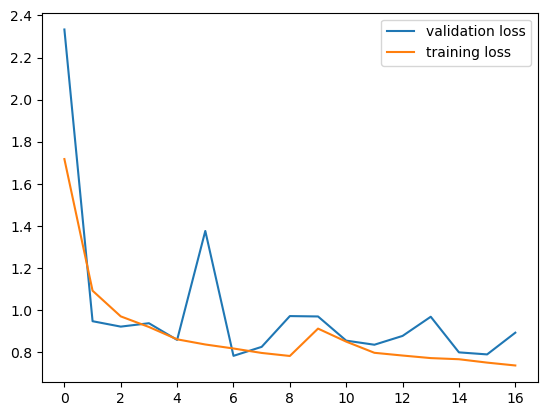

In [167]:
plt.plot(deep_history.history['val_loss'],label='validation loss')
plt.plot(deep_history.history['loss'],label='training loss')
plt.legend()
plt.show()

In [168]:
y_pred_deep = model.predict(test_gen)

63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 239ms/step


In [169]:
pred_classes_deep = y_pred1.argmax(axis=1)
pred_classes_deep = pred_classes1[:test_gen.samples] ## get the first 1992 out of 13944 data so that the shape for confusion matrix is the same

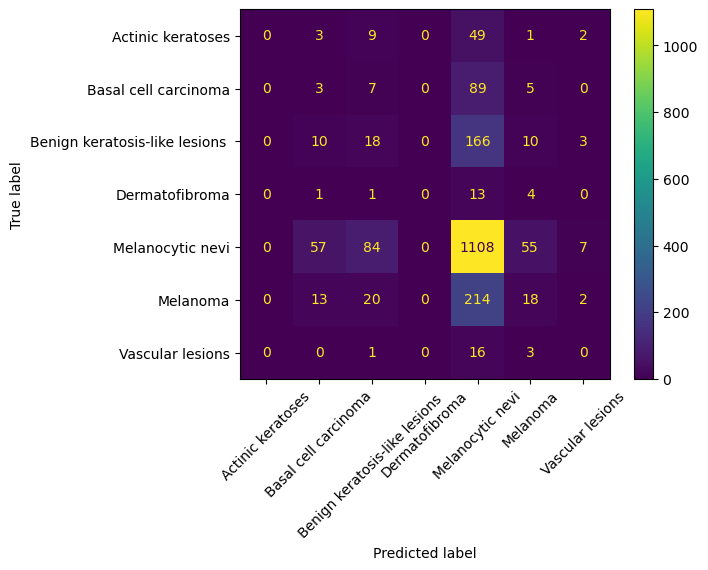

In [170]:
ConfusionMatrixDisplay.from_predictions(test_gen.classes, pred_classes_deep, display_labels=class_names, xticks_rotation=45)
plt.show()

In [171]:
t_lost, t_acc = deep_model.evaluate(test_gen, verbose=1)
t_acc

63/63 ━━━━━━━━━━━━━━━━━━━━ 23s 359ms/step - accuracy: 0.7083 - loss: 0.7840


0.7083333134651184

## Building the Transfer Learning Models

In [155]:
def create_transfer_learning_model(model_name):

    if model_name == 'MobileNetV2': 
        base_model = MobileNetV2(weights = 'imagenet', include_top=False, input_shape=(224, 224, 3))
    elif model_name == 'ResNet50': 
        base_model = ResNet50(weights = 'imagenet', include_top=False, input_shape=(224, 224, 3))   
    elif model_name == 'VGG16': 
        base_model = VGG16(weights = 'imagenet', include_top=False, input_shape=(224, 224, 3))
    else: 
        print('Unknown Transfer Learning model')

    ## build the model
    base_model.trainable = False
    
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(512,activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(256,activation='relu'),
        # BatchNormalization(),
        Dropout(0.5),
        Dense(512,activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        # Dense(256,activation='relu'),
        # BatchNormalization(),
        # Dropout(0.5),
        Dense(units=num_classes,activation='softmax')
    ])

    return model

# Create transfer learning model with MobileNetV2
mobilenet_model = create_transfer_learning_model('MobileNetV2')
mobilenet_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_3           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ (None, 512)                 │         655,872 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_21 (Dropout)                 │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_26 (Dense)                     │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_22 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_27 (Dense)                     │ (None, 512)                 │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_13               │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_23 (Dropout)                 │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_28 (Dense)                     │ (None, 7)                   │           3,591 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,184,455 (12.15 MB)

 Trainable params: 924,423 (3.53 MB)

 Non-trainable params: 2,260,032 (8.62 MB)

In [49]:
mobilenet_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',metrics=['accuracy'])

early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True
)

history = mobilenet_model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=20,
    callbacks=[early_stopping]
)

Epoch 1/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 165s 648ms/step - accuracy: 0.5294 - loss: 1.6506 - val_accuracy: 0.6993 - val_loss: 0.8835
Epoch 2/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 156s 630ms/step - accuracy: 0.6508 - loss: 1.1150 - val_accuracy: 0.7134 - val_loss: 0.8346
Epoch 3/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 156s 630ms/step - accuracy: 0.6783 - loss: 0.9654 - val_accuracy: 0.7103 - val_loss: 0.7904
Epoch 4/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 157s 631ms/step - accuracy: 0.6901 - loss: 0.9048 - val_accuracy: 0.7314 - val_loss: 0.7826
Epoch 5/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 157s 634ms/step - accuracy: 0.6969 - loss: 0.8694 - val_accuracy: 0.7209 - val_loss: 0.8054
Epoch 6/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 153s 617ms/step - accuracy: 0.6961 - loss: 0.8478 - val_accuracy: 0.7159 - val_loss: 0.7806
Epoch 7/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 159s 639ms/step - accuracy: 0.7094 - loss: 0.8274 - val_accuracy: 0.7108 - val_loss: 0.7898
Epoch 8/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 207s 836ms/step - accuracy: 0.7135 -

<Axes: >

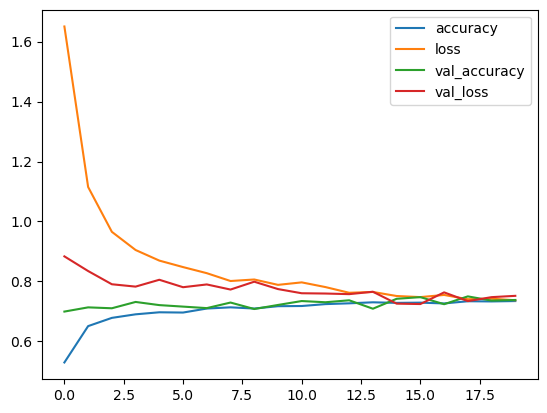

In [50]:
pd.DataFrame(history.history).plot()

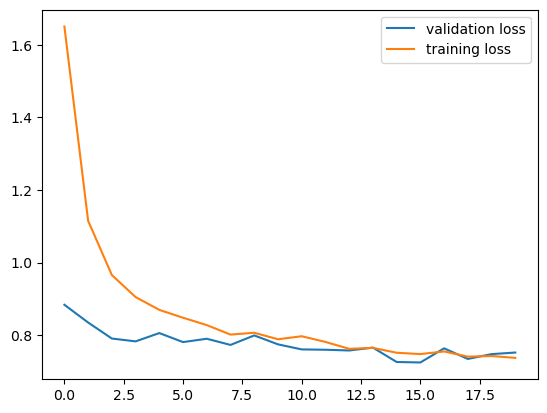

In [52]:
plt.plot(history.history['val_loss'],label='validation loss')
plt.plot(history.history['loss'],label='training loss')
plt.legend()
plt.show()

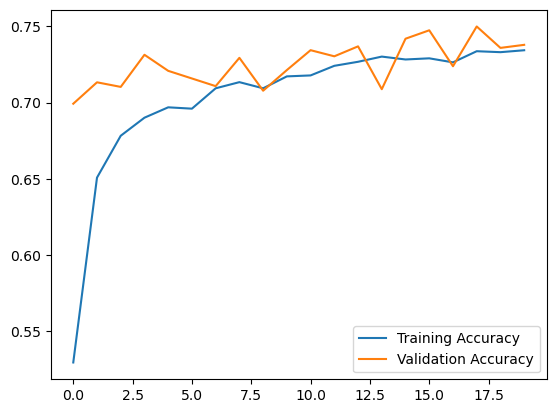

In [181]:
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.legend()
plt.show()

In [53]:
y_pred = mobilenet_model.predict(test_gen)

63/63 ━━━━━━━━━━━━━━━━━━━━ 24s 357ms/step


In [54]:
pred_classes = y_pred.argmax(axis=1)
pred_classes = pred_classes[:test_gen.samples] ## get the first 1992 out of 13944 data so that the shape for confusion matrix is the same

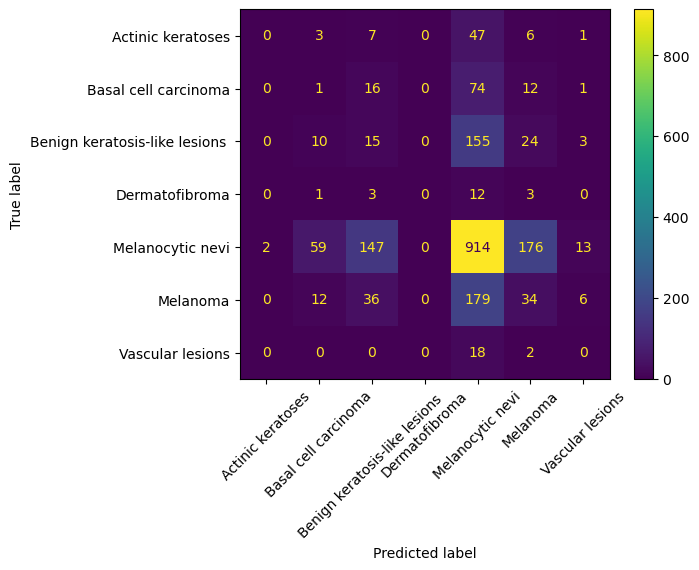

In [55]:
ConfusionMatrixDisplay.from_predictions(test_gen.classes,pred_classes, display_labels=class_names, xticks_rotation=45)
plt.show()

In [56]:
t_lost,t_acc = mobilenet_model.evaluate(test_gen, verbose=1)
t_acc

63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 333ms/step - accuracy: 0.7475 - loss: 0.7244


0.7474899888038635

MobileNetV2 model has the highest accuracy among the 3 models. 

### Testing the Best CNN Model's Predictions with Sample Images

ISIC_0029325.jpg
ISIC_0029334.jpg
ISIC_0029341.jpg
ISIC_0029371.jpg
ISIC_0029377.jpg
ISIC_0029382.jpg
ISIC_0029386.jpg
ISIC_0029396.jpg


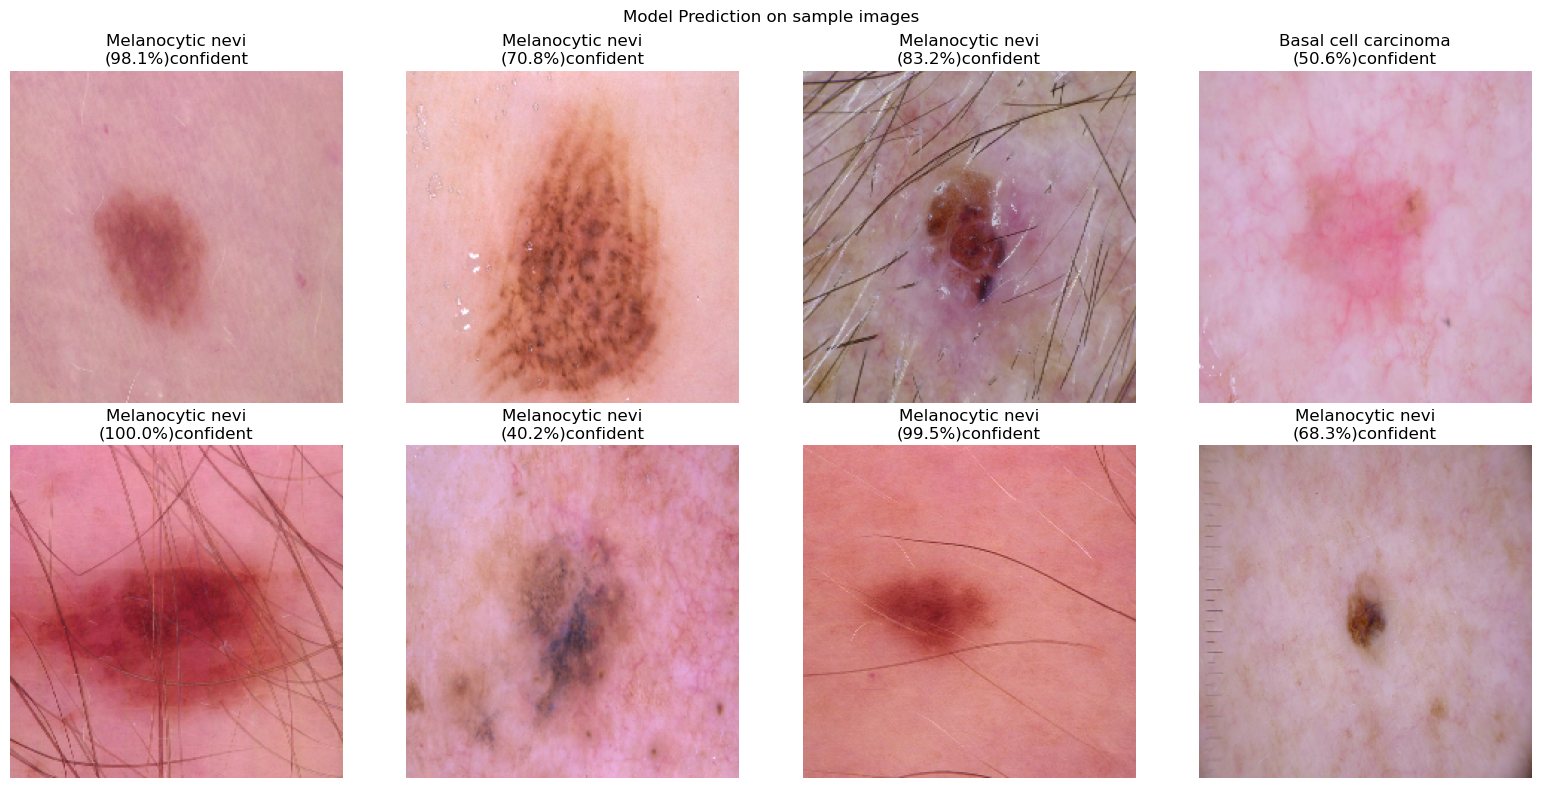

In [195]:
sample_images = [f for f in os.listdir(SAMPLE_DIR) if f.endswith(('.jpg', '.jpeg', '.png', '.webp'))]

fig, axes = plt.subplots(2,4,figsize=(16,8))
axes = axes.flatten()

for i, img_name in enumerate(sample_images[:8]): 
    print(img_name)
    img_path = os.path.join(SAMPLE_DIR, img_name)
    img = image.load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array/255.0

    pred = loaded_model.predict(img_array, verbose=0)[0]
    pred_class_idx = np.argmax(pred)
    confidence = pred[pred_class_idx] * 100
    pred_label = class_names[pred_class_idx]
    # print(pred)

    axes[i].imshow(img)
    axes[i].set_title(f'{pred_label}\n({confidence:.1f}%)confident')
    axes[i].axis('off')
plt.suptitle('Model Prediction on sample images')
plt.tight_layout()
plt.show()

In [59]:
mobilenet_model.save('./good_model_skin_cancer.keras')

In [144]:
patient_df.to_csv('patient_data_cleaned.csv')

In [179]:
loaded_model = tf.keras.models.load_model('good_model_skin_cancer.keras')

In [180]:
t_lost,t_acc = loaded_model.evaluate(test_gen, verbose=1)
t_acc

63/63 ━━━━━━━━━━━━━━━━━━━━ 25s 366ms/step - accuracy: 0.7475 - loss: 0.7244


0.7474899888038635